# Sales & Customer Analysis
Analisis data Online Retail (Dec 2010 - Dec 2011) menggunakan Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
df = pd.read_excel("Online_Retail.xlsx")

In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,"17,850.00",United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,"17,850.00",United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,"13,047.00",United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386048,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


## Data Cleaning

In [6]:
df_clean = df.copy()
total_awal = len(df_clean)

df_clean = df_clean[df_clean["CustomerID"].notna()]
print(f"1. Hapus CustomerID NaN  : {total_awal - len(df_clean):,} baris dibuang")
print(f"   Data tersisa          : {len(df_clean):,} baris")

total_sebelum = len(df_clean)
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
print(f"2. Hapus pembatalan (C)  : {total_sebelum - len(df_clean):,} baris dibuang")
print(f"   Data tersisa          : {len(df_clean):,} baris")

total_sebelum = len(df_clean)
df_clean = df_clean[df_clean["Quantity"] > 0]
print(f"3. Hapus Quantity <= 0   : {total_sebelum - len(df_clean):,} baris dibuang")
print(f"   Data tersisa          : {len(df_clean):,} baris")

total_sebelum = len(df_clean)
df_clean = df_clean[df_clean["UnitPrice"] > 0]
print(f"4. Hapus UnitPrice <= 0  : {total_sebelum - len(df_clean):,} baris dibuang")
print(f"   Data tersisa          : {len(df_clean):,} baris")

df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

print("\n================== HASIL CLEANING ==================")
print(f"Data awal   : {total_awal:,} baris")
print(f"Data bersih : {len(df_clean):,} baris  ({len(df_clean)/total_awal*100:.1f}% dipertahankan)")
print(f"Jumlah customer unik : {df_clean['CustomerID'].nunique():,}")
print(f"Total revenue        : GBP {df_clean['TotalPrice'].sum():,.2f}")
print("\nCek missing value setelah cleaning:")
print(df_clean.isna().sum())

1. Hapus CustomerID NaN  : 135,080 baris dibuang
   Data tersisa          : 406,829 baris


2. Hapus pembatalan (C)  : 8,905 baris dibuang
   Data tersisa          : 397,924 baris
3. Hapus Quantity <= 0   : 0 baris dibuang
   Data tersisa          : 397,924 baris
4. Hapus UnitPrice <= 0  : 40 baris dibuang
   Data tersisa          : 397,884 baris



================== HASIL CLEANING ==================
Data awal   : 541,909 baris
Data bersih : 397,884 baris  (73.4% dipertahankan)
Jumlah customer unik : 4,338
Total revenue        : GBP 8,911,407.90

Cek missing value setelah cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Year           0
Month          0
YearMonth      0
dtype: int64


In [7]:
print(f"Duplicate rows : {df_clean.duplicated().sum()}")
df_clean = df_clean.drop_duplicates()
print(f"After drop duplicates : {len(df_clean):,} rows")

Duplicate rows : 5192


After drop duplicates : 392,692 rows


In [8]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,15.30,2010,12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010,12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,22.00,2010,12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010,12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010,12,2010-12


# EDA

========== STATISTIK DESKRIPTIF ==========
        Quantity  UnitPrice  TotalPrice
count 392,692.00 392,692.00  392,692.00
mean       13.12       3.13       22.63
std       180.49      22.24      311.10
min         1.00       0.00        0.00
25%         2.00       1.25        4.95
50%         6.00       1.95       12.45
75%        12.00       3.75       19.80
max    80,995.00   8,142.75  168,469.60


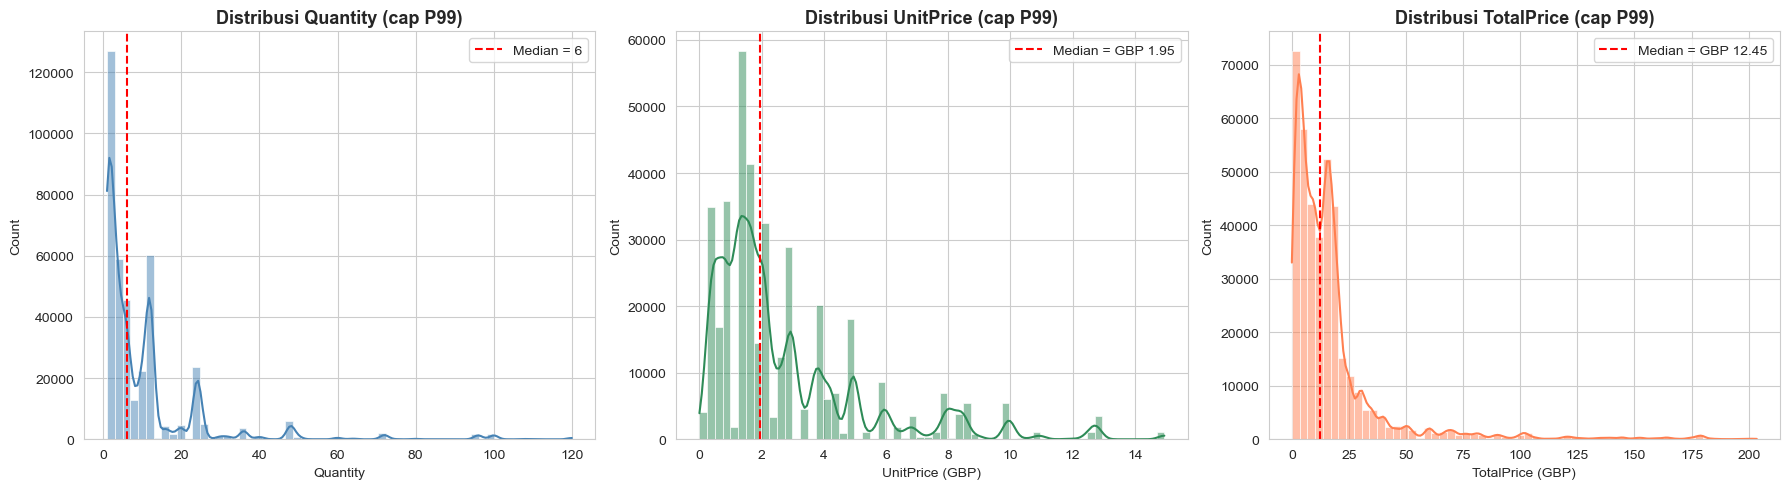

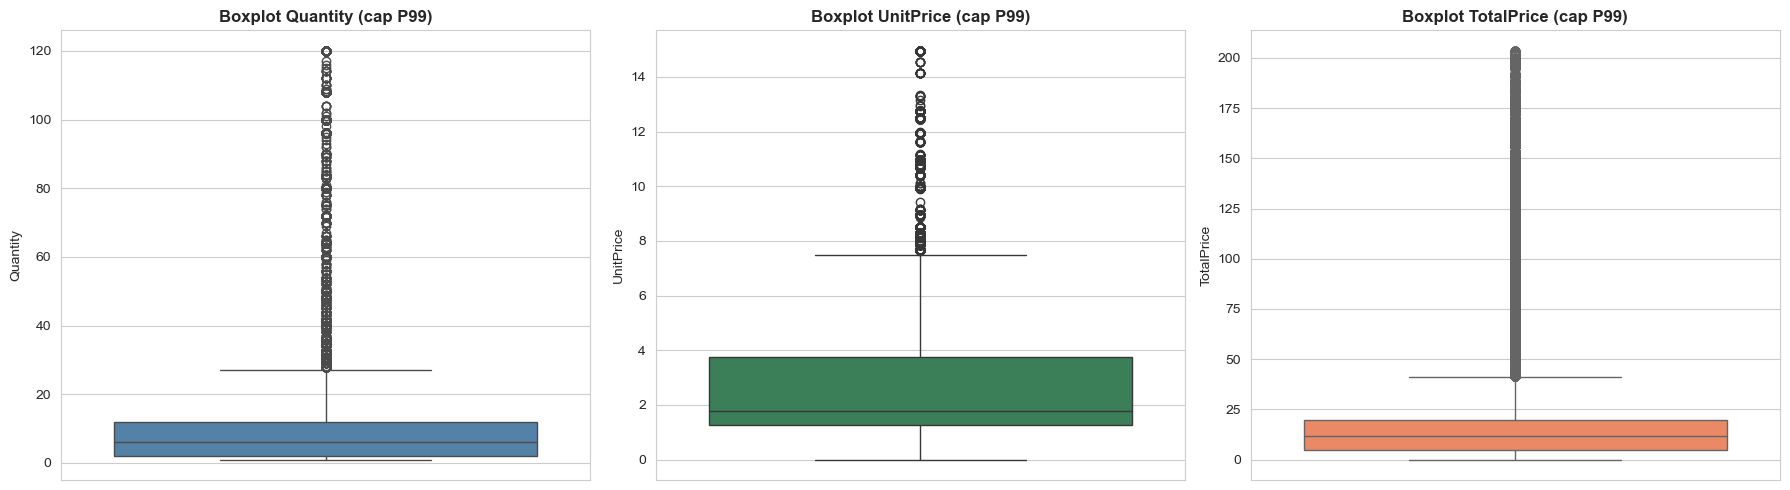

In [9]:
# ================== EDA 1: Statistik Deskriptif & Distribusi ==================
print("========== STATISTIK DESKRIPTIF ==========")
print(df_clean[["Quantity", "UnitPrice", "TotalPrice"]].describe().to_string())

# Cap outlier di persentil 99 untuk visualisasi
qty_cap = df_clean["Quantity"].quantile(0.99)
price_cap = df_clean["UnitPrice"].quantile(0.99)
total_cap = df_clean["TotalPrice"].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean[df_clean["Quantity"] <= qty_cap]["Quantity"], bins=60, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Distribusi Quantity (cap P99)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Quantity")
axes[0].axvline(df_clean["Quantity"].median(), color="red", linestyle="--", label=f"Median = {df_clean['Quantity'].median():.0f}")
axes[0].legend()

sns.histplot(df_clean[df_clean["UnitPrice"] <= price_cap]["UnitPrice"], bins=60, kde=True, color="seagreen", ax=axes[1])
axes[1].set_title("Distribusi UnitPrice (cap P99)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("UnitPrice (GBP)")
axes[1].axvline(df_clean["UnitPrice"].median(), color="red", linestyle="--", label=f"Median = GBP {df_clean['UnitPrice'].median():.2f}")
axes[1].legend()

sns.histplot(df_clean[df_clean["TotalPrice"] <= total_cap]["TotalPrice"], bins=60, kde=True, color="coral", ax=axes[2])
axes[2].set_title("Distribusi TotalPrice (cap P99)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("TotalPrice (GBP)")
axes[2].axvline(df_clean["TotalPrice"].median(), color="red", linestyle="--", label=f"Median = GBP {df_clean['TotalPrice'].median():.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()

# Boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df_clean[df_clean["Quantity"] <= qty_cap]["Quantity"], color="steelblue", ax=axes[0])
axes[0].set_title("Boxplot Quantity (cap P99)", fontweight="bold")
sns.boxplot(y=df_clean[df_clean["UnitPrice"] <= price_cap]["UnitPrice"], color="seagreen", ax=axes[1])
axes[1].set_title("Boxplot UnitPrice (cap P99)", fontweight="bold")
sns.boxplot(y=df_clean[df_clean["TotalPrice"] <= total_cap]["TotalPrice"], color="coral", ax=axes[2])
axes[2].set_title("Boxplot TotalPrice (cap P99)", fontweight="bold")
plt.tight_layout()
plt.show()

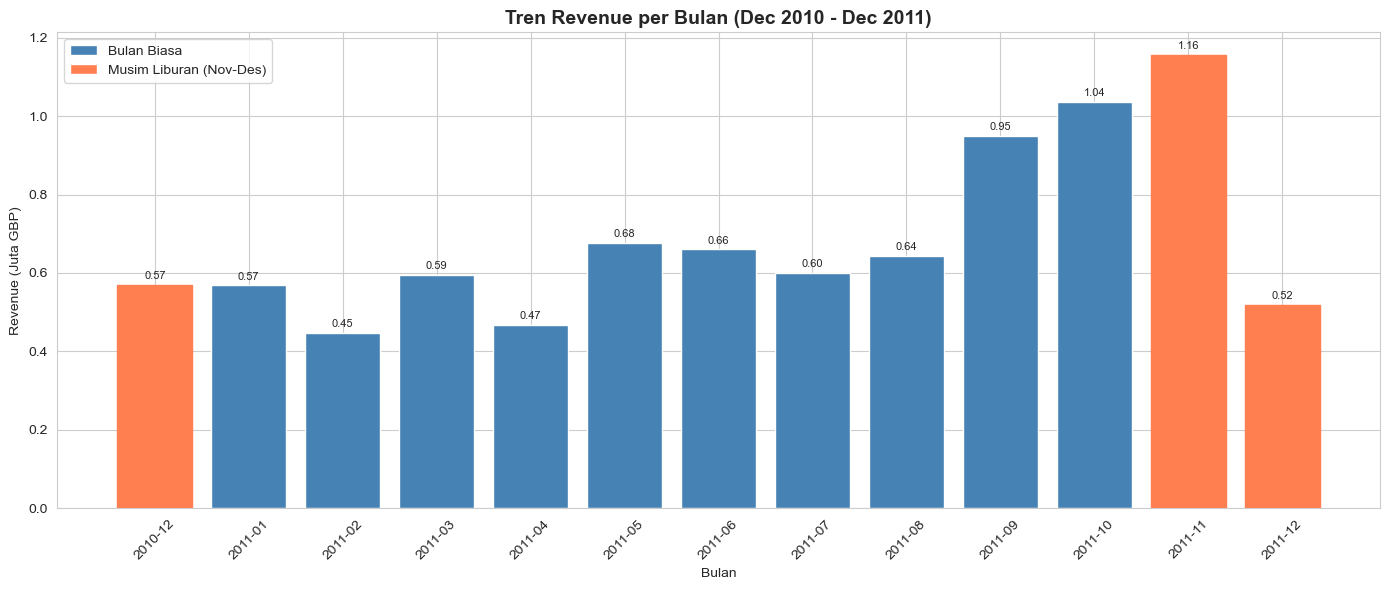

========== RINGKASAN REVENUE BULANAN ==========
YearMonth   TotalPrice
  2010-12   570,422.73
  2011-01   568,101.31
  2011-02   446,084.92
  2011-03   594,081.76
  2011-04   468,374.33
  2011-05   677,355.15
  2011-06   660,046.05
  2011-07   598,962.90
  2011-08   644,051.04
  2011-09   950,690.20
  2011-10 1,035,642.45
  2011-11 1,156,205.61
  2011-12   517,190.44

Bulan revenue tertinggi : 2011-11
Revenue tertinggi        : GBP 1,156,205.61
Rata-rata revenue/bulan  : GBP 683,631.45

Rata-rata revenue Q4 (Okt-Des) : GBP 819,865.31
Rata-rata revenue Non-Q4        : GBP 623,083.07


In [10]:
# ================== EDA 2: Tren Revenue per Bulan ==================
monthly_revenue = df_clean.groupby("YearMonth")["TotalPrice"].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values("YearMonth")

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(monthly_revenue["YearMonth"], monthly_revenue["TotalPrice"] / 1e6, color="steelblue", edgecolor="white")

for i, row in monthly_revenue.iterrows():
    month_num = int(row["YearMonth"].split("-")[1])
    if month_num in [11, 12]:
        bars[i].set_color("coral")

ax.set_title("Tren Revenue per Bulan (Dec 2010 - Dec 2011)", fontsize=14, fontweight="bold")
ax.set_xlabel("Bulan")
ax.set_ylabel("Revenue (Juta GBP)")
ax.tick_params(axis="x", rotation=45)

for i, row in monthly_revenue.iterrows():
    ax.text(i, row["TotalPrice"] / 1e6 + 0.01, f"{row['TotalPrice']/1e6:.2f}",
            ha="center", va="bottom", fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", label="Bulan Biasa"),
                   Patch(facecolor="coral", label="Musim Liburan (Nov-Des)")]
ax.legend(handles=legend_elements, loc="upper left")
plt.tight_layout()
plt.show()

print("========== RINGKASAN REVENUE BULANAN ==========")
print(monthly_revenue[["YearMonth", "TotalPrice"]].to_string(index=False))
print(f"\nBulan revenue tertinggi : {monthly_revenue.loc[monthly_revenue['TotalPrice'].idxmax(), 'YearMonth']}")
print(f"Revenue tertinggi        : GBP {monthly_revenue['TotalPrice'].max():,.2f}")
print(f"Rata-rata revenue/bulan  : GBP {monthly_revenue['TotalPrice'].mean():,.2f}")

monthly_revenue["Is_Q4"] = monthly_revenue["YearMonth"].apply(
    lambda x: "Q4 (Okt-Des)" if int(x.split("-")[1]) in [10, 11, 12] else "Non-Q4"
)
q4_comparison = monthly_revenue.groupby("Is_Q4")["TotalPrice"].mean()
print(f"\nRata-rata revenue Q4 (Okt-Des) : GBP {q4_comparison.get('Q4 (Okt-Des)', 0):,.2f}")
print(f"Rata-rata revenue Non-Q4        : GBP {q4_comparison.get('Non-Q4', 0):,.2f}")

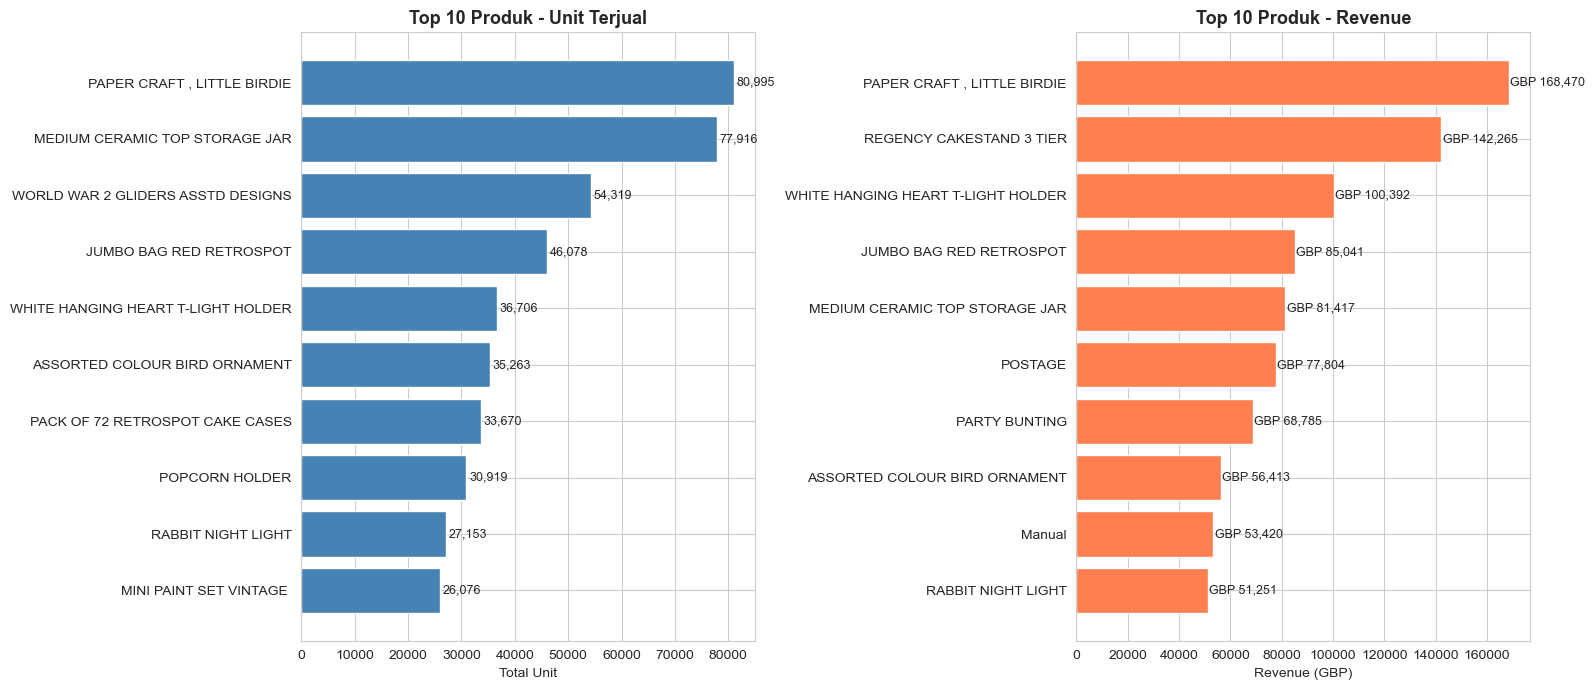

========== TOP 10 PRODUK (UNIT) ==========
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076

========== TOP 10 PRODUK (REVENUE) ==========
Description
PAPER CRAFT , LITTLE BIRDIE          168,469.60
REGENCY CAKESTAND 3 TIER             142,264.75
WHITE HANGING HEART T-LIGHT HOLDER   100,392.10
JUMBO BAG RED RETROSPOT               85,040.54
MEDIUM CERAMIC TOP STORAGE JAR        81,416.73
POSTAGE                               77,803.96
PARTY BUNTING                         68,785.23
ASSORTED COLOUR BIRD ORNAMENT         56,413.03
Manual                                53,419.93
RABBIT NIGHT L

In [11]:
# ================== EDA 3: Top 10 Produk ==================

top_units = df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_revenue = df_clean.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

bars1 = axes[0].barh(top_units.index[::-1], top_units.values[::-1], color="steelblue")
axes[0].set_title("Top 10 Produk - Unit Terjual", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Total Unit")
for bar, val in zip(bars1, top_units.values[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f"{val:,.0f}", va="center", fontsize=9)

bars2 = axes[1].barh(top_revenue.index[::-1], top_revenue.values[::-1], color="coral")
axes[1].set_title("Top 10 Produk - Revenue", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Revenue (GBP)")
for bar, val in zip(bars2, top_revenue.values[::-1]):
    axes[1].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f"GBP {val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("========== TOP 10 PRODUK (UNIT) ==========")
print(top_units.to_string())
print(f"\n========== TOP 10 PRODUK (REVENUE) ==========")
print(top_revenue.to_string())

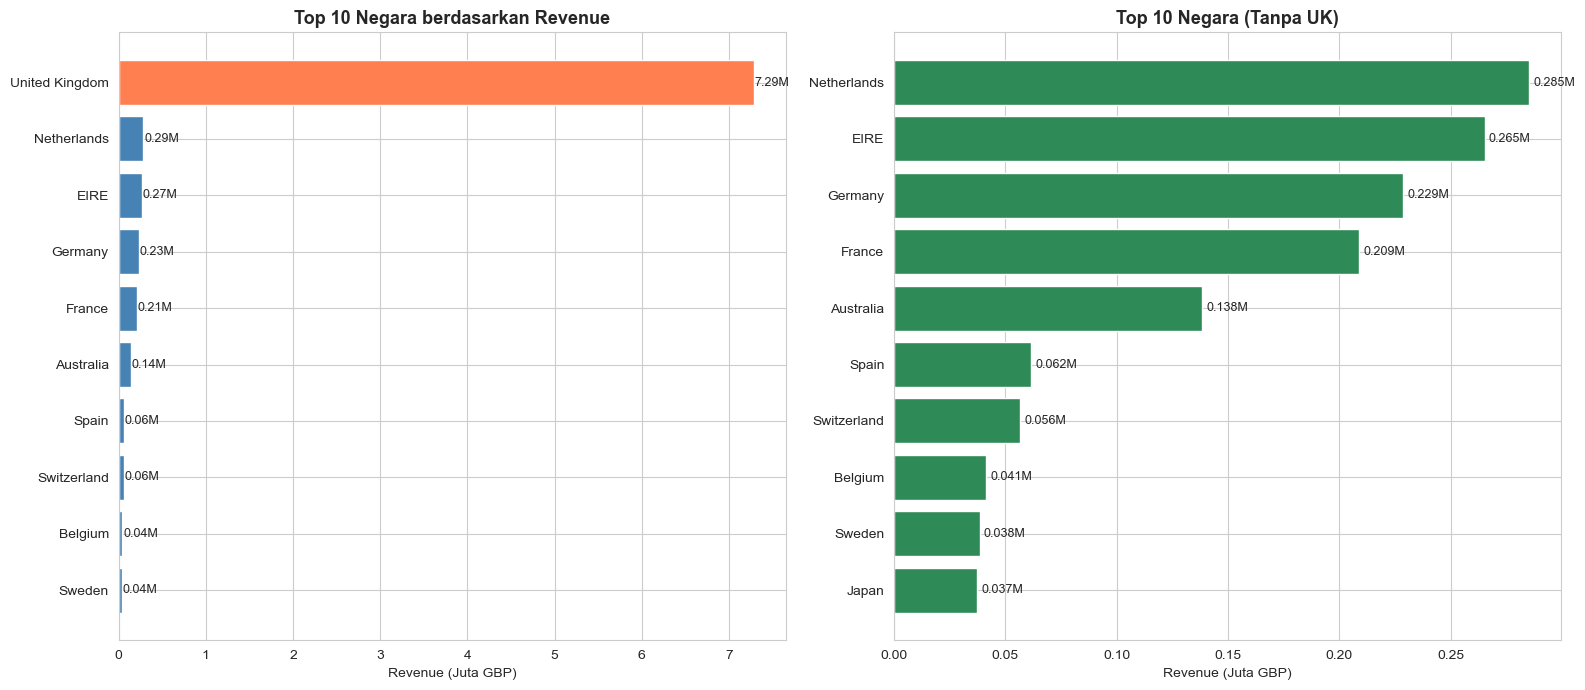


Kontribusi UK : 82.0% dari total revenue
Top 10 negara menyumbang 96.9% revenue


In [12]:
# ================== EDA 4: Top 10 Negara (Revenue) ==================

country_revenue = df_clean.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
top_countries = country_revenue.head(10)
top_no_uk = country_revenue.drop("United Kingdom", errors="ignore").head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors1 = ["coral" if c == "United Kingdom" else "steelblue" for c in top_countries.index]
bars1 = axes[0].barh(top_countries.index[::-1], top_countries.values[::-1] / 1e6, color=colors1[::-1])
axes[0].set_title("Top 10 Negara berdasarkan Revenue", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Revenue (Juta GBP)")
for bar, val in zip(bars1, top_countries.values[::-1] / 1e6):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}M", va="center", fontsize=9)

bars2 = axes[1].barh(top_no_uk.index[::-1], top_no_uk.values[::-1] / 1e6, color="seagreen")
axes[1].set_title("Top 10 Negara (Tanpa UK)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Revenue (Juta GBP)")
for bar, val in zip(bars2, top_no_uk.values[::-1] / 1e6):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}M", va="center", fontsize=9)

plt.tight_layout()
plt.show()

uk_pct = country_revenue["United Kingdom"] / country_revenue.sum() * 100
print(f"\nKontribusi UK : {uk_pct:.1f}% dari total revenue")
print(f"Top 10 negara menyumbang {(top_countries.sum() / country_revenue.sum() * 100):.1f}% revenue")

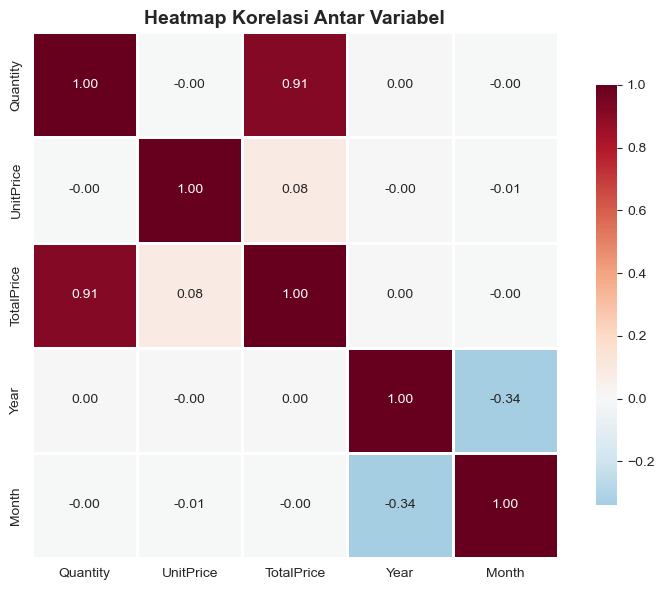

========== INTERPRETASI KORELASI ==========
- TotalPrice berkorelasi kuat dengan Quantity (karena TotalPrice = Qty x UnitPrice)
- Quantity dan UnitPrice berkorelasi rendah -> volume & harga relatif independen


In [13]:
# ================== EDA 5: Heatmap Korelasi ==================

corr_cols = ["Quantity", "UnitPrice", "TotalPrice", "Year", "Month"]
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Heatmap Korelasi Antar Variabel", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("========== INTERPRETASI KORELASI ==========")
print("- TotalPrice berkorelasi kuat dengan Quantity (karena TotalPrice = Qty x UnitPrice)")
print("- Quantity dan UnitPrice berkorelasi rendah -> volume & harga relatif independen")

## Tahap 3 - RFM Analysis

RFM (Recency, Frequency, Monetary) adalah metode segmentasi customer berdasarkan perilaku transaksi.

- **Recency**: berapa hari sejak transaksi terakhir (cutoff `2011-12-09`)
- **Frequency**: berapa kali customer melakukan transaksi
- **Monetary**: total belanja customer

Semakin tinggi skor (1-4) semakin baik, kecuali Recency (semakin dekat hari ini = skor tinggi).

In [14]:
# ================== TAHAP 3: RFM ANALYSIS ==================
from datetime import timedelta

CUTOFF = pd.Timestamp("2011-12-09")

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (CUTOFF - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

print("Statistik RFM:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().to_string())

Statistik RFM:
       Recency  Frequency   Monetary
count 4,338.00   4,338.00   4,338.00
mean     91.06       4.27   2,048.69
std     100.01       7.70   8,985.23
min      -1.00       1.00       3.75
25%      16.00       1.00     306.48
50%      49.00       2.00     668.57
75%     140.75       5.00   1,660.60
max     372.00     209.00 280,206.02


In [15]:
# Skor kuartil 1-4 (Recency dibalik: hari kecil = skor tinggi)
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

def rfm_segment(r):
    if r.R_score >= 3 and r.F_score >= 3 and r.M_score >= 3:
        return "Champions"
    if r.R_score >= 2 and r.F_score >= 3 and r.M_score >= 3:
        return "Loyal Customers"
    if r.R_score >= 3 and r.F_score >= 2:
        return "Potential Loyalists"
    if r.R_score == 1 and r.F_score >= 2:
        return "At Risk"
    return "Lost Customers"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

print("\n===== SEGMENTASI RFM =====")
print(rfm.groupby("Segment").agg(
    n=("CustomerID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFreq=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
).round(1).to_string())


===== SEGMENTASI RFM =====
                        n  AvgRecency  AvgFreq  AvgMonetary
Segment                                                    
At Risk               566      230.70     2.20       804.20
Champions            1315       15.50     9.40     4,929.70
Lost Customers       1490      135.30     1.30       485.50
Loyal Customers       362       81.00     4.70     2,009.30
Potential Loyalists   605       21.50     2.20       824.20


### Visualisasi RFM

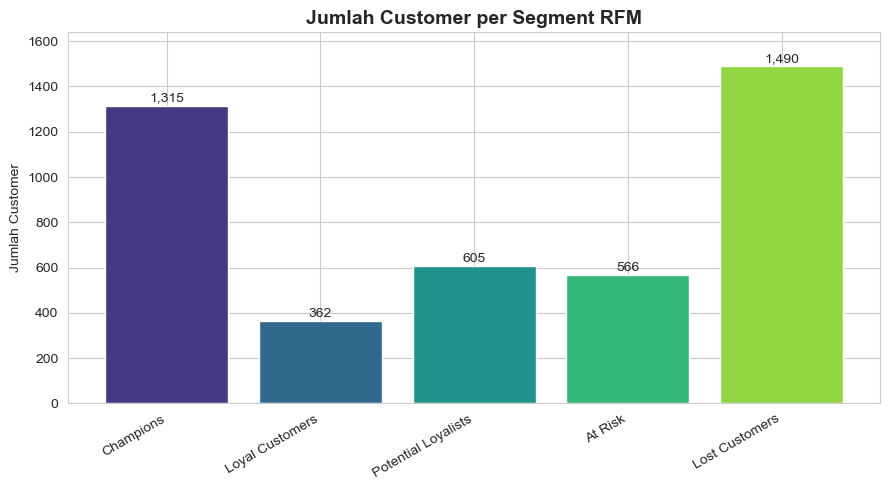

In [16]:
# Visualisasi jumlah customer per segment
fig, ax = plt.subplots(figsize=(9, 5))
order = ["Champions", "Loyal Customers", "Potential Loyalists", "At Risk", "Lost Customers"]
counts = rfm["Segment"].value_counts().reindex(order)
colors = sns.color_palette("viridis", n_colors=len(order))
bars = ax.bar(order, counts.values, color=colors)
for b, c in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, c + 5, f"{c:,}", ha="center", va="bottom", fontsize=10)
ax.set_title("Jumlah Customer per Segment RFM", fontsize=14, fontweight="bold")
ax.set_ylabel("Jumlah Customer"); ax.set_ylim(0, counts.max() * 1.1)
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## Tahap 4 - K-Means Clustering

Mengelompokkan customer dengan **K-Means** berdasarkan nilai RFM yang telah distandarisasi (`StandardScaler`).
Jumlah cluster dipilih dengan metode **elbow** dan **silhouette score**.

In [17]:
# ================== TAHAP 4: K-MEANS ==================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ["Recency", "Frequency", "Monetary"]

# Winsorize outlier (persentil 1-99) agar clustering tidak didominasi 1-2 customer ekstrem.
# Nilai RFM asli tetap tersimpan di kolom rfm untuk interpretasi & ekspor.
rfm_clip = rfm[features].clip(lower=rfm[features].quantile(0.01),
                              upper=rfm[features].quantile(0.99), axis=1)
scaler = StandardScaler()
X = scaler.fit_transform(rfm_clip)

# Cari k terbaik: elbow & silhouette (k=2..8)
Ks = range(2, 9)
inertias, sil = [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

best_k = Ks[int(np.argmax(sil))]
print("Silhouette per k:", dict(zip(Ks, [round(s, 3) for s in sil])))
print(f"K terbaik berdasarkan silhouette: {best_k}")

Silhouette per k: {2: 0.66, 3: 0.54, 4: 0.536, 5: 0.474, 6: 0.447, 7: 0.427, 8: 0.424}
K terbaik berdasarkan silhouette: 2


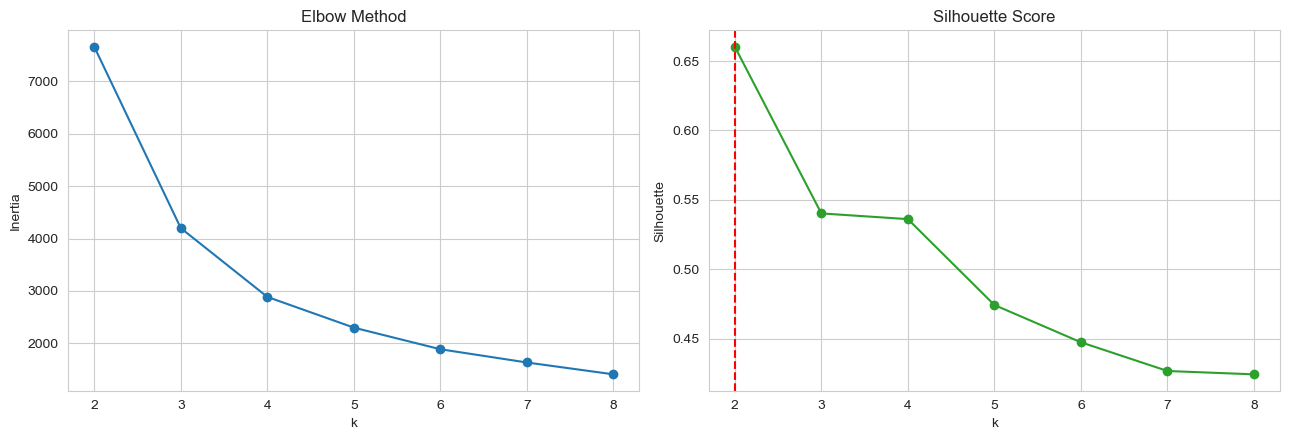

In [18]:
# Plot elbow & silhouette
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(Ks), inertias, "o-", color="tab:blue")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(Ks), sil, "o-", color="tab:green")
axes[1].axvline(best_k, ls="--", color="r"); axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

In [19]:
# Jalankan K-Means dgn k terbaik
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X)

profil = rfm.groupby("Cluster").agg(
    n=("CustomerID", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
).round(1)

centroid = pd.DataFrame(kmeans.cluster_centers_, columns=features).round(2)

print("Profil cluster (skala asli):")
print(profil.to_string())
print("\nCentroid (skala standar):")
print(centroid.to_string())

Profil cluster (skala asli):
            n  Recency  Frequency  Monetary
Cluster                                    
0        4027    96.90       3.00  1,000.60
1         311    15.80      21.30 15,620.40

Centroid (skala standar):
   Recency  Frequency  Monetary
0     0.06      -0.22     -0.21
1    -0.75       2.80      2.75


In [20]:
# Nama segment berdasarkan karakteristik centroid (z-score)
def name_cluster(z):
    if z.Recency < -0.5 and z.Frequency > 0.5 and z.Monetary > 0.5:
        return "Champions"
    if z.Recency < -0.2 and z.Frequency > 0 and z.Monetary > 0:
        return "Loyal Customers"
    if z.Recency < 0 and z.Monetary <= 0:
        return "Potential Customers"
    if z.Recency > 0.5:
        return "Lost Customers"
    if z.Recency > 0.3 and (z.Frequency < 0 or z.Monetary < 0):
        return "At-Risk Customers"
    return "General Customers"

centroid["Cluster_Name"] = centroid.apply(name_cluster, axis=1)
rfm = rfm.merge(centroid[["Cluster_Name"]], left_on="Cluster", right_index=True)

print("\nJumlah customer per cluster:")
print(rfm.groupby(["Cluster", "Cluster_Name"]).agg(n=("CustomerID", "count")).to_string())


Jumlah customer per cluster:
                              n
Cluster Cluster_Name           
0       General Customers  4027
1       Champions           311


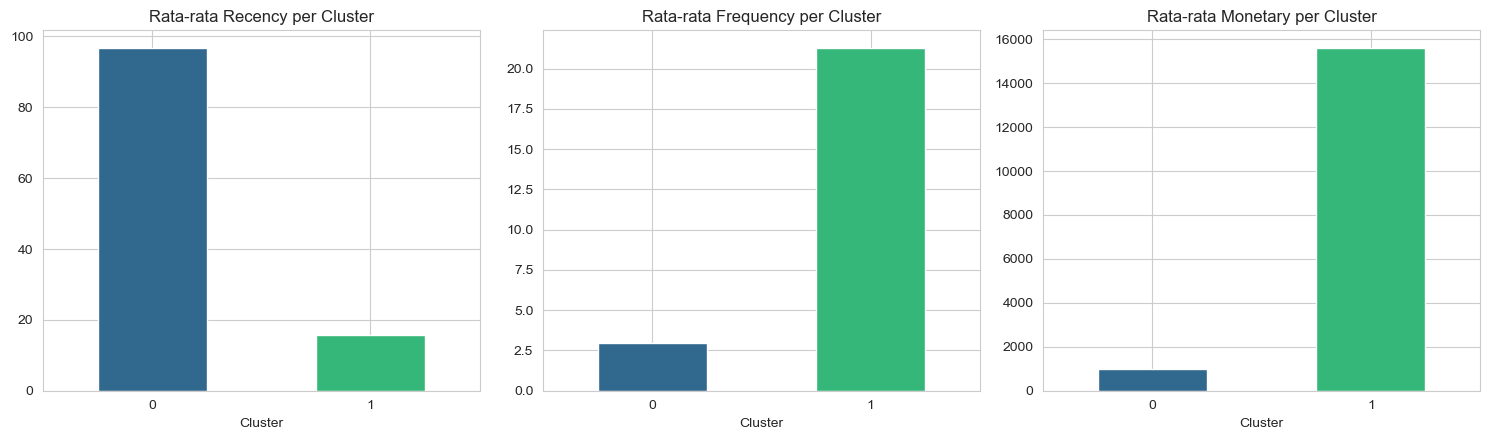

In [21]:
# Visualisasi profil tiap cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, f in enumerate(features):
    rfm.groupby("Cluster")[f].mean().plot(kind="bar", ax=axes[i],
                                          color=sns.color_palette("viridis", best_k))
    axes[i].set_title(f"Rata-rata {f} per Cluster")
    axes[i].set_xlabel("Cluster"); axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## Tahap 5 - Cohort Analysis & CLV

**Cohort analysis** mengelompokkan customer berdasarkan bulan transaksi pertama, lalu mengukur
berapa persen yang masih aktif pada bulan-bulan berikutnya (retention). Dari sini kita hitung
**churn rate** dan **Customer Lifetime Value (CLV)** sederhana.

In [22]:
# ================== TAHAP 5: COHORT & CLV ==================
df_sort = df_clean.sort_values("InvoiceDate").copy()
df_sort["OrderMonth"] = df_sort["InvoiceDate"].dt.to_period("M")

# Cohort = bulan transaksi pertama tiap customer
cohort = df_sort.groupby("CustomerID")["OrderMonth"].min().rename("Cohort")
df_sort = df_sort.join(cohort, on="CustomerID")

# Indeks bulan sejak transaksi pertama
df_sort["CohortIndex"] = (df_sort["OrderMonth"] - df_sort["Cohort"]).apply(lambda x: x.n)

cohort_size = df_sort.groupby("Cohort")["CustomerID"].nunique().rename("Size").reset_index()
retention = (df_sort.groupby(["Cohort", "CohortIndex"])["CustomerID"].nunique()
             .rename("ActiveCustomers").reset_index())
retention = retention.merge(cohort_size, on="Cohort")
retention["Retention"] = retention["ActiveCustomers"] / retention["Size"]
retention_pivot = retention.pivot_table(index="Cohort", columns="CohortIndex", values="Retention").round(3)

print("Retention rate per cohort (%):")
print((retention_pivot * 100).round(1).to_string())

Retention rate per cohort (%):
CohortIndex     0     1     2     3     4     5     6     7     8     9     10    11    12
Cohort                                                                                    
2010-12     100.00 36.60 32.30 38.40 36.30 39.80 36.30 34.90 35.40 39.50 37.40 50.30 26.60
2011-01     100.00 22.10 26.60 23.00 32.10 28.80 24.70 24.20 30.00 32.60 36.50 11.80   NaN
2011-02     100.00 18.70 18.70 28.40 27.10 24.70 25.30 27.90 24.70 30.50  6.80   NaN   NaN
2011-03     100.00 15.00 25.20 19.90 22.30 16.80 26.80 23.00 27.90  8.60   NaN   NaN   NaN
2011-04     100.00 21.30 20.30 21.00 19.70 22.70 21.70 26.00  7.30   NaN   NaN   NaN   NaN
2011-05     100.00 19.00 17.30 17.30 20.80 23.20 26.40  9.50   NaN   NaN   NaN   NaN   NaN
2011-06     100.00 17.40 15.70 26.40 23.10 33.50  9.50   NaN   NaN   NaN   NaN   NaN   NaN
2011-07     100.00 18.10 20.70 22.30 27.10 11.20   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2011-08     100.00 20.70 24.90 24.30 12.40   NaN   NaN   Na

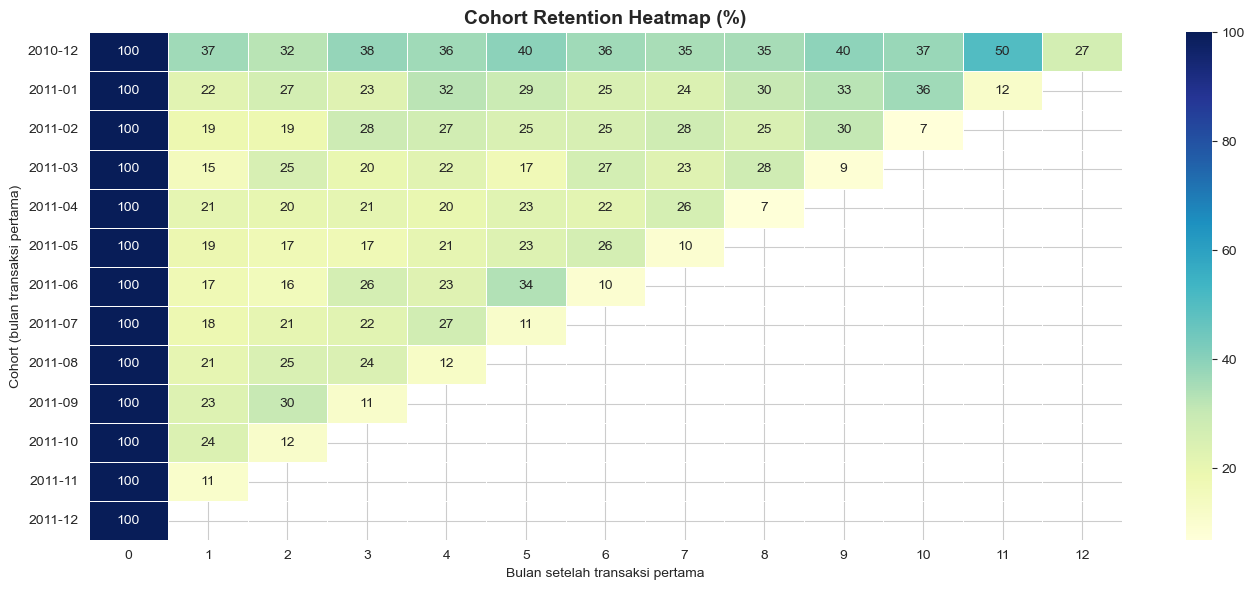

In [23]:
# Heatmap retention
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(retention_pivot * 100, annot=True, fmt=".0f", cmap="YlGnBu",
            linewidths=0.5, ax=ax)
ax.set_title("Cohort Retention Heatmap (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Bulan setelah transaksi pertama")
ax.set_ylabel("Cohort (bulan transaksi pertama)")
plt.tight_layout(); plt.show()

In [24]:
# Churn rate = 1 - retention rata-rata bulan ke-1
avg_ret_m1 = retention[retention["CohortIndex"] == 1]["Retention"].mean()
churn_rate = 1 - avg_ret_m1
print(f"Rata-rata retention bulan ke-1: {avg_ret_m1*100:.1f}%")
print(f"Churn rate (bulanan)         : {churn_rate*100:.1f}%")

# CLV sederhana per customer
df_sort["Lifespan"] = (df_sort["OrderMonth"] - df_sort["Cohort"]).apply(lambda x: x.n + 1)
clv = df_sort.groupby("CustomerID").agg(
    Total=("TotalPrice", "sum"), Orders=("InvoiceNo", "nunique"), Lifespan=("Lifespan", "max"),
).reset_index()
clv["AOV"] = clv["Total"] / clv["Orders"]                       # average order value
clv["PurchaseFreq"] = clv["Orders"] / clv["Lifespan"]           # frekuensi belanja per bulan
clv["CLV"] = clv["AOV"] * clv["PurchaseFreq"] * clv["Lifespan"] # AOV x Freq x Umur

print(f"\nRata-rata CLV per customer : GBP {clv['CLV'].mean():,.2f}")
print(clv.describe().round(2).to_string())

Rata-rata retention bulan ke-1: 20.6%
Churn rate (bulanan)         : 79.4%



Rata-rata CLV per customer : GBP 2,048.69
       CustomerID      Total   Orders  Lifespan       AOV  PurchaseFreq        CLV
count    4,338.00   4,338.00 4,338.00  4,338.00  4,338.00      4,338.00   4,338.00
mean    15,300.41   2,048.69     4.27      5.26    417.65          0.92   2,048.69
std      1,721.81   8,985.23     7.70      4.31  1,796.51          0.83   8,985.23
min     12,346.00       3.75     1.00      1.00      3.45          0.15       3.75
25%     13,813.25     306.48     1.00      1.00    177.87          0.54     306.48
50%     15,299.50     668.57     2.00      4.00    291.94          1.00     668.57
75%     16,778.75   1,660.60     5.00      9.00    428.28          1.00   1,660.60
max     18,287.00 280,206.02   209.00     13.00 84,236.25         34.00 280,206.02


## Tahap 6 - Output & Rekomendasi

Ekspor seluruh hasil analisis ke folder `output/` dan susun rekomendasi bisnis per segment.

In [25]:
# ================== TAHAP 6: OUTPUT ==================
import os
os.makedirs("output", exist_ok=True)

# 1. Rekap revenue bulanan
monthly_rev = df_sort.groupby("OrderMonth")["TotalPrice"].sum().reset_index()
monthly_rev.columns = ["Month", "Revenue"]
monthly_rev.to_csv("output/sales_monthly.csv", index=False)

# 2. Skor RFM per customer
rfm[["CustomerID", "Recency", "Frequency", "Monetary",
     "R_score", "F_score", "M_score", "RFM_score", "Segment", "Cluster", "Cluster_Name"]] \
    .to_csv("output/rfm_scores.csv", index=False)

# 3. Segmentasi customer
rfm[["CustomerID", "Recency", "Frequency", "Monetary", "RFM_score", "Segment", "Cluster_Name"]] \
    .to_csv("output/customer_segments.csv", index=False)

# 4. Tabel retention
retention_pivot.reset_index().to_csv("output/cohort_retention.csv", index=False)

# 5. Ringkasan gabungan (excel)
summary = pd.DataFrame({
    "Metric": ["Total Revenue (GBP)", "N Customer", "Avg Recency (days)", "Avg Frequency",
               "Avg Monetary (GBP)", "N Cluster K-Means", "Avg Retention Month-1 (%)",
               "Churn Rate (%)", "Avg CLV (GBP)"],
    "Value": [f"{df_sort['TotalPrice'].sum():,.2f}", f"{rfm['CustomerID'].nunique():,}",
              f"{rfm['Recency'].mean():.1f}", f"{rfm['Frequency'].mean():.2f}",
              f"{rfm['Monetary'].mean():,.2f}", f"{best_k}",
              f"{avg_ret_m1*100:.1f}", f"{churn_rate*100:.1f}", f"{clv['CLV'].mean():,.2f}"],
})

seg_summary = rfm.groupby("Segment")["CustomerID"].count().rename("Customer Count").reset_index()
seg_summary["Pct (%)"] = (seg_summary["Customer Count"] / seg_summary["Customer Count"].sum() * 100).round(1)

with pd.ExcelWriter("output/insights_summary.xlsx", engine="openpyxl") as w:
    summary.to_excel(w, sheet_name="Summary", index=False)
    seg_summary.to_excel(w, sheet_name="RFM Segments", index=False)
    rfm[["CustomerID", "Recency", "Frequency", "Monetary", "R_score", "F_score",
         "M_score", "Segment", "Cluster_Name"]].to_excel(w, sheet_name="RFM Scores", index=False)
    profil.reset_index().to_excel(w, sheet_name="Cluster Profile", index=False)
    retention_pivot.reset_index().to_excel(w, sheet_name="Cohort Retention", index=False)
    clv[["CustomerID", "Total", "Orders", "Lifespan", "AOV", "PurchaseFreq", "CLV"]] \
        .to_excel(w, sheet_name="CLV", index=False)

print("Berhasil mengekspor ke folder output/ :")
for f in sorted(os.listdir("output")):
    print("  -", f)

Berhasil mengekspor ke folder output/ :
  - cohort_retention.csv
  - customer_segments.csv
  - insights_summary.xlsx
  - rfm_scores.csv
  - sales_monthly.csv


### Rekomendasi Bisnis per Segment

In [26]:
# ================== REKOMENDASI ==================
rekomendasi = {
    "Champions": ("Customer paling berharga & paling aktif. "
                  "Beri reward & program loyalitas eksklusif, tawarkan akses awal ke produk baru, "
                  "dan minta referral. Pertahankan dengan layanan personal."),
    "Loyal Customers": ("Sering bertransaksi dan bernilai tinggi. "
                        "Pertahankan dengan komunikasi rutin, rekomendasi personal, dan diskon ringan "
                        "agar naik kelas menjadi Champions."),
    "Potential Loyalists": ("Baru saja aktif dan cukup sering membeli. "
                            "Dorong ke Loyal/Champions dengan bundle produk, insentif repeat purchase, "
                            "dan reminder keranjang belanja."),
    "At Risk": ("Mulai tidak aktif dalam 1-2 bulan. "
                "Re-engage cepat dengan email win-back, diskon terbatas, atau survei kepuasan. "
                "Fokus utama karena potensi churn tinggi."),
    "Lost Customers": ("Sudah lama tidak bertransaksi. "
                       "Evaluasi penyebab churn, jalankan kampanye reaktivasi besar (penawaran khusus), "
                       "atau hentikan alokasi biaya pemasaran jika tidak merespons."),
}

print("========== REKOMENDASI BISNIS PER SEGMENT ==========\n")
for seg, reko in rekomendasi.items():
    n = rfm[rfm["Segment"] == seg].shape[0]
    print(f"• {seg} ({n:,} customer)")
    print(f"  {reko}\n")

print("K-Means Clusters -> berikut nama segmentnya:")
for c, name in centroid[["Cluster_Name"]].itertuples():
    n = rfm[rfm["Cluster"] == c].shape[0]
    print(f"  Cluster {c} = {name} ({n:,} customer)")

========== REKOMENDASI BISNIS PER SEGMENT ==========

• Champions (1,315 customer)
  Customer paling berharga & paling aktif. Beri reward & program loyalitas eksklusif, tawarkan akses awal ke produk baru, dan minta referral. Pertahankan dengan layanan personal.

• Loyal Customers (362 customer)
  Sering bertransaksi dan bernilai tinggi. Pertahankan dengan komunikasi rutin, rekomendasi personal, dan diskon ringan agar naik kelas menjadi Champions.

• Potential Loyalists (605 customer)
  Baru saja aktif dan cukup sering membeli. Dorong ke Loyal/Champions dengan bundle produk, insentif repeat purchase, dan reminder keranjang belanja.

• At Risk (566 customer)
  Mulai tidak aktif dalam 1-2 bulan. Re-engage cepat dengan email win-back, diskon terbatas, atau survei kepuasan. Fokus utama karena potensi churn tinggi.

• Lost Customers (1,490 customer)
  Sudah lama tidak bertransaksi. Evaluasi penyebab churn, jalankan kampanye reaktivasi besar (penawaran khusus), atau hentikan alokasi biaya pem